# PART A — TABULAR DATA
## Pima Indians Diabetes Dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/archive (4).zip')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in zero_columns:
    print(col, ":", (df[col] == 0).sum())

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0


In [ ]:
df[zero_columns] = df[zero_columns].replace(0, np.nan)

In [ ]:
for col in zero_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


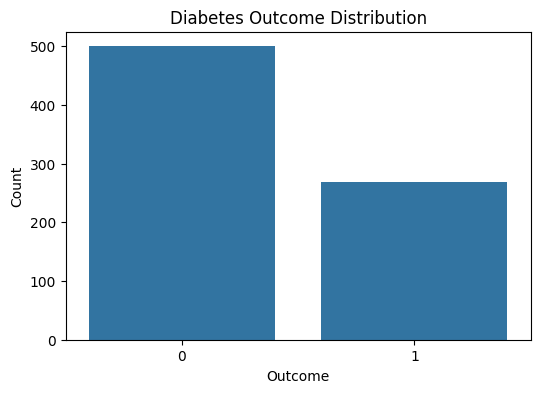

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df)

plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

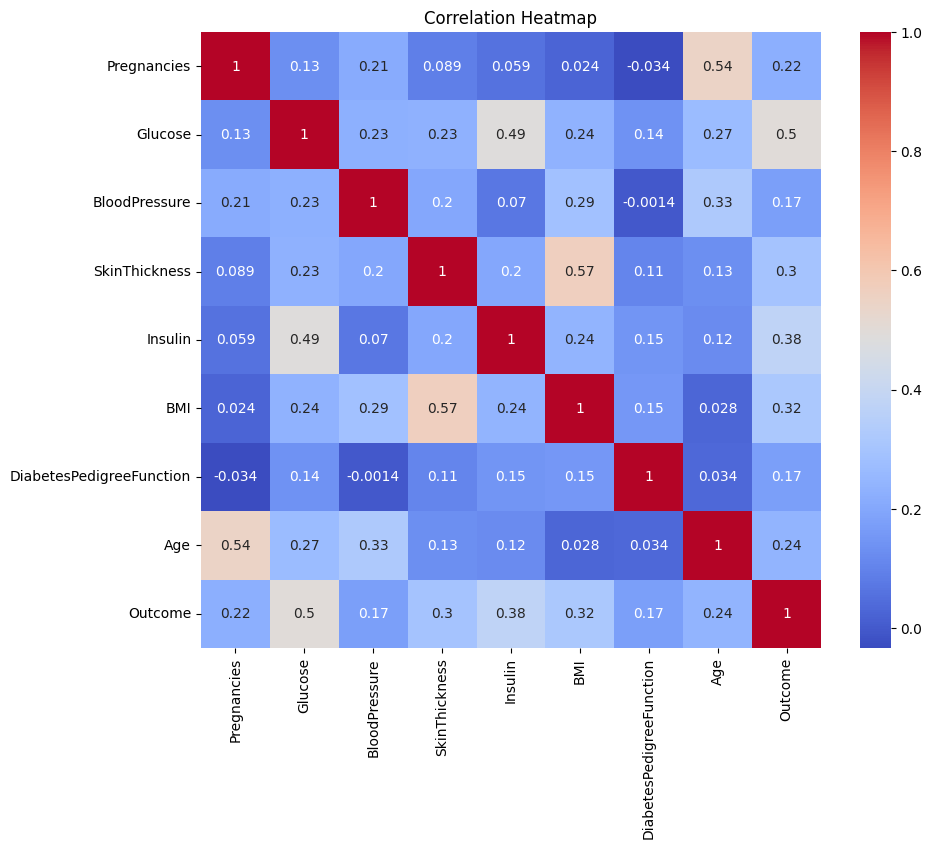

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

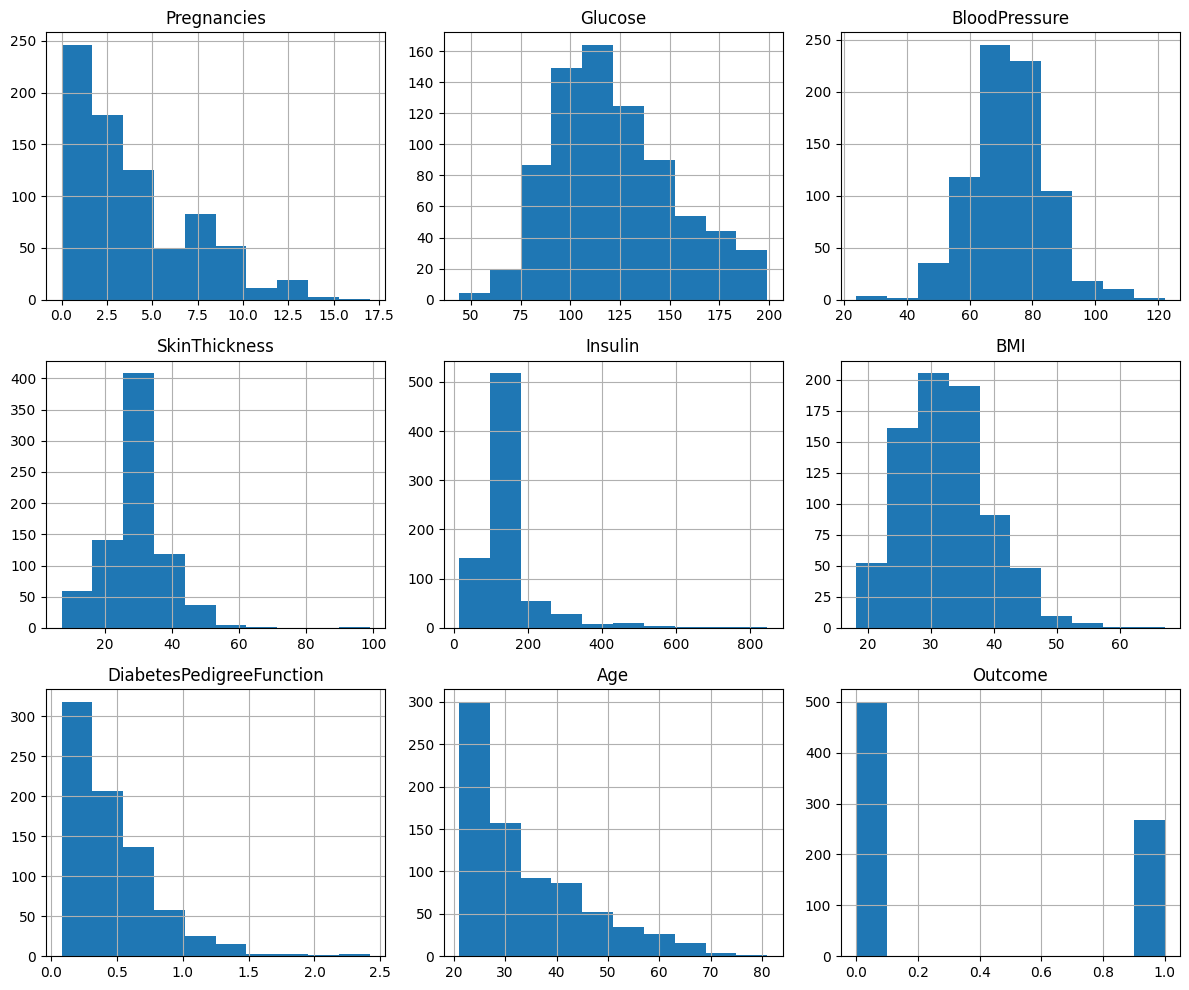

In [ ]:
df.hist(figsize=(12,10))

plt.tight_layout()
plt.show()

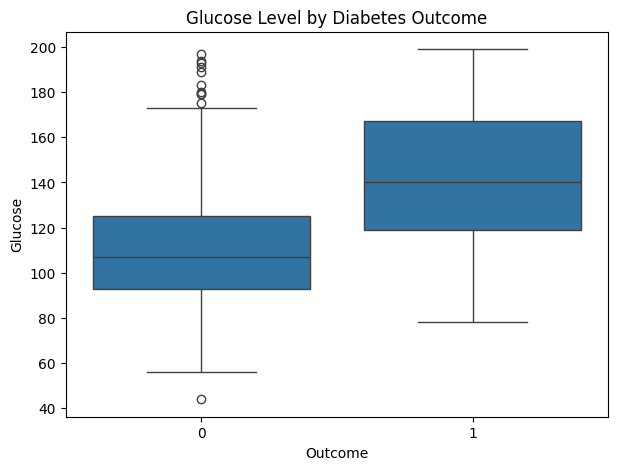

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title('Glucose Level by Diabetes Outcome')
plt.show()

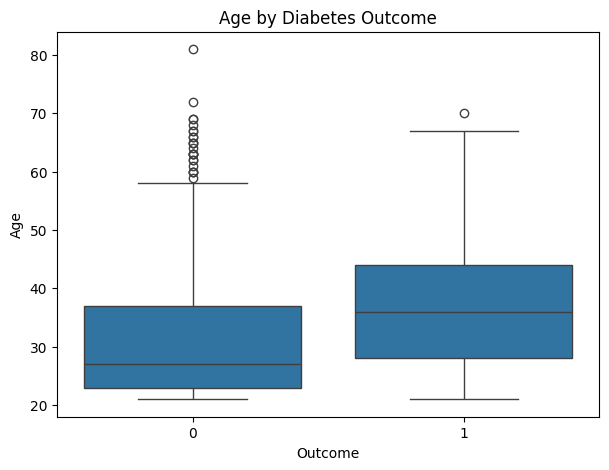

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Outcome', y='Age', data=df)

plt.title('Age by Diabetes Outcome')
plt.show()

In [ ]:
diabetic = df[df['Outcome'] == 1]['Glucose']
non_diabetic = df[df['Outcome'] == 0]['Glucose']

t_stat, p_value = stats.ttest_ind(diabetic, non_diabetic)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 15.808983160790056
P-value: 6.22693313370198e-49


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference.")
else:
    print("Fail to reject H0: No statistically significant difference.")

Reject H0: There is a statistically significant difference.


In [ ]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 50, 100],
    labels=['Young', 'Middle', 'Older']
)

In [ ]:
contingency_table = pd.crosstab(
    df['Age_Group'],
    df['Outcome']
)

print(contingency_table)

Outcome      0    1
Age_Group          
Young      327   90
Middle     130  140
Older       43   38


In [ ]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2_stat)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 71.85015965734874
P-value: 2.4999773184934036e-16
Degrees of freedom: 2


In [ ]:
if p_value < 0.05:
    print("Reject H0: Age group and diabetes outcome are associated.")
else:
    print("Fail to reject H0: No significant association.")

Reject H0: Age group and diabetes outcome are associated.


In [ ]:
df['BMI_Group'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [ ]:
groups = [
    group['Glucose'].dropna()
    for name, group in df.groupby('BMI_Group', observed=True)
]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 13.50087815825635
P-value: 1.3657943712769507e-08


In [ ]:
if p_value < 0.05:
    print("Reject H0: Mean glucose differs significantly among BMI groups.")
else:
    print("Fail to reject H0: No significant difference among BMI groups.")

Reject H0: Mean glucose differs significantly among BMI groups.


In [ ]:
df['Glucose_BMI_Ratio'] = df['Glucose'] / df['BMI']

df['Age_Glucose_Interaction'] = df['Age'] * df['Glucose']

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group,BMI_Group,Glucose_BMI_Ratio,Age_Glucose_Interaction
0,6,148,72.0,35,169.5,33.6,0.627,50,1,Middle,Obese,4.404762,7400
1,1,85,66.0,29,102.5,26.6,0.351,31,0,Middle,Overweight,3.195489,2635
2,8,183,64.0,32,169.5,23.3,0.672,32,1,Middle,Normal,7.854077,5856
3,1,89,66.0,23,94.0,28.1,0.167,21,0,Young,Overweight,3.167260,1869
4,0,137,40.0,35,168.0,43.1,2.288,33,1,Middle,Obese,3.178654,4521


In [ ]:
X = df.drop(columns=['Outcome', 'Age_Group', 'BMI_Group'])
y = df['Outcome']

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI_Ratio,Age_Glucose_Interaction
0,0.639947,0.864625,-0.032180,0.665181,0.311604,0.169483,0.468492,1.425995,0.485672,1.566179
1,-0.844885,-1.204727,-0.528124,-0.010112,-0.440843,-0.848549,-0.365061,-0.190672,-0.613731,-0.723648
2,1.233880,2.014265,-0.693438,0.327535,0.311604,-1.328478,0.604397,-0.105584,3.621594,0.824208
3,-0.844885,-1.073339,-0.528124,-0.685405,-0.536303,-0.630399,-0.920763,-1.041549,-0.639395,-1.091750
4,-1.141852,0.503310,-2.677212,0.665181,0.294758,1.551096,5.484909,-0.020496,-0.629035,0.182672


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Feature Selection
selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
for feature in selected_features:
    print(feature)

Selected Features:
Glucose
SkinThickness
Insulin
BMI
Age_Glucose_Interaction


In [ ]:
# Display feature scores

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

feature_scores = feature_scores.sort_values(
    by='Score',
    ascending=False
)

print("Feature Scores:")
display(feature_scores)

Feature Scores:


,Feature,Score
1,Glucose,249.923949
9,Age_Glucose_Interaction,156.362828
4,Insulin,126.971455
5,BMI,84.722280
3,SkinThickness,73.089964
7,Age,46.140611
0,Pregnancies,39.670227
8,Glucose_BMI_Ratio,25.710804
2,BloodPressure,24.048567
6,DiabetesPedigreeFunction,23.871300


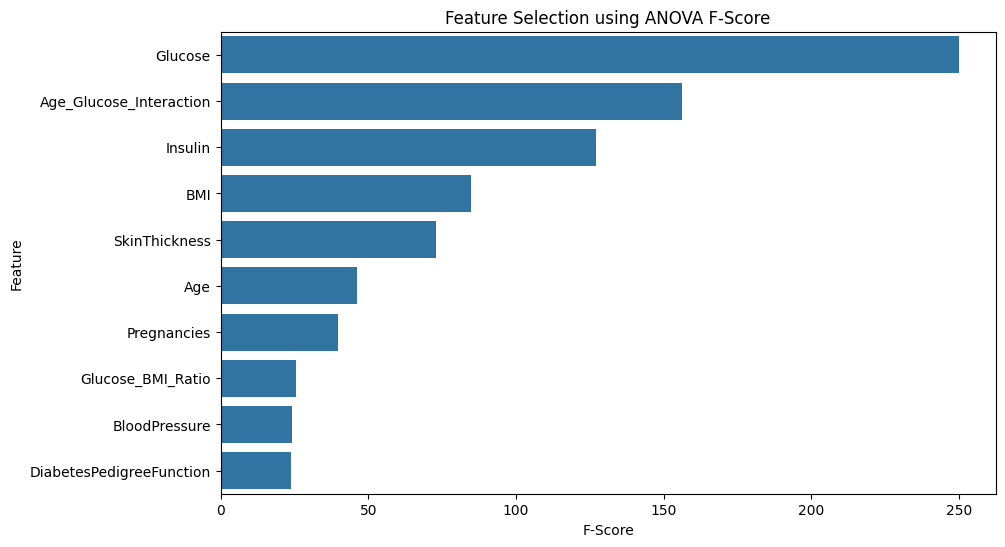

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Score',
    y='Feature',
    data=feature_scores
)

plt.title('Feature Selection using ANOVA F-Score')
plt.xlabel('F-Score')
plt.ylabel('Feature')

plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA for feature extraction
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of extracted components:", X_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original number of features: 10
Number of extracted components: 2
Explained variance ratio: [0.32365233 0.19938749]
Total explained variance: 0.5230398210473963


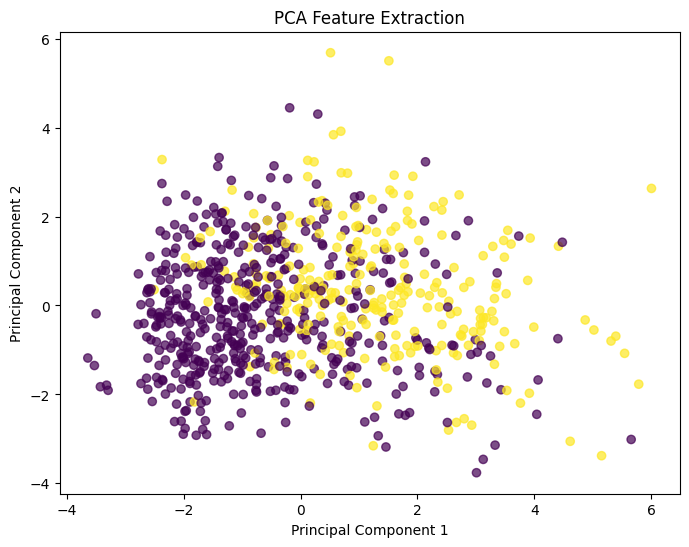

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Feature Extraction')

plt.show()

# PART B — TEXTUAL DATA
## MTSamples Medical Transcriptions


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

import warnings
warnings.filterwarnings("ignore")

In [ ]:
text_df = pd.read_csv('/content/archive (5) (1).zip')

text_df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
print("Number of rows:", text_df.shape[0])
print("Number of columns:", text_df.shape[1])

Number of rows: 4999
Number of columns: 6


In [ ]:
text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [ ]:
text_df.describe(include='all')

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
count,4999.000000,4999,4999,4999,4966,3931
unique,NaN,2348,40,2377,2357,3849
top,NaN,An example/template for a routine normal male...,Surgery,Lumbar Discogram,"PREOPERATIVE DIAGNOSIS: , Low back pain.,POSTO...",
freq,NaN,12,1103,5,5,81
mean,2499.000000,NaN,NaN,NaN,NaN,NaN
std,1443.231328,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1249.500000,NaN,NaN,NaN,NaN,NaN
50%,2499.000000,NaN,NaN,NaN,NaN,NaN
75%,3748.500000,NaN,NaN,NaN,NaN,NaN


In [ ]:
text_df.columns

Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')

In [ ]:
text_df.isnull().sum()

,0
Unnamed: 0,0
description,0
medical_specialty,0
sample_name,0
transcription,33
keywords,1068


In [ ]:
text_df.columns.tolist()

['Unnamed: 0',
 'description',
 'medical_specialty',
 'sample_name',
 'transcription',
 'keywords']

In [ ]:
text_df.head(3)

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [ ]:
print(text_df.shape)
print(text_df.columns.tolist())

(4999, 6)
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [ ]:
text_df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
text_df.isnull().sum()

,0
Unnamed: 0,0
description,0
medical_specialty,0
sample_name,0
transcription,33
keywords,1068


In [ ]:
print("Number of duplicate rows:", text_df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
text_df = text_df.drop(columns=['Unnamed: 0'])

text_df.head()

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
print("Rows:", text_df.shape[0])
print("Columns:", text_df.shape[1])
print(text_df.columns.tolist())

Rows: 4999
Columns: 5
['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [ ]:
print("Missing transcriptions:", text_df['transcription'].isnull().sum())

Missing transcriptions: 33


In [ ]:
text_df = text_df.dropna(subset=['transcription']).copy()

print("Rows after removing missing transcriptions:", text_df.shape[0])

Rows after removing missing transcriptions: 4966


In [ ]:
text_columns = [
    'description',
    'medical_specialty',
    'sample_name',
    'keywords'
]

for col in text_columns:
    text_df[col] = text_df[col].fillna('')

In [ ]:
text_df.isnull().sum()

,0
description,0
medical_specialty,0
sample_name,0
transcription,0
keywords,0


In [ ]:
print("Duplicate transcriptions:",
      text_df['transcription'].duplicated().sum())

Duplicate transcriptions: 2609


In [ ]:
text_columns = [
    'description',
    'medical_specialty',
    'sample_name',
    'keywords'
]

for col in text_columns:
    text_df[col] = text_df[col].fillna('')

In [ ]:
text_df.isnull().sum()

,0
description,0
medical_specialty,0
sample_name,0
transcription,0
keywords,0


In [ ]:
print("Duplicate transcriptions:",
      text_df['transcription'].duplicated().sum())

Duplicate transcriptions: 2609


In [ ]:
text_df = text_df.drop_duplicates(subset=['transcription']).copy()

print("Dataset shape after removing duplicates:", text_df.shape)

Dataset shape after removing duplicates: (2357, 5)


In [ ]:
import re

def remove_phi(text):
    text = str(text)


    text = re.sub(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        '[EMAIL]',
        text
    )


    text = re.sub(
        r'\b(?:\+?\d{1,3}[-.\s]?)?(?:\(?\d{3}\)?[-.\s]?)?\d{3}[-.\s]?\d{4}\b',
        '[PHONE]',
        text
    )


    text = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        '[DATE]',
        text
    )


    text = re.sub(
        r'\b\d{6,}\b',
        '[ID]',
        text
    )

    return text

In [ ]:
text_df['transcription_clean'] = text_df['transcription'].apply(remove_phi)

In [ ]:
text_df[['transcription', 'transcription_clean']].head()

,transcription,transcription_clean
0,"SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This 23-year-old white female pr..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","PAST MEDICAL HISTORY:, He has difficulty climb..."
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...","2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,1. The left ventricular cavity size and wall ...,1. The left ventricular cavity size and wall ...


In [ ]:
def clean_text(text):
    text = str(text).lower()


    text = re.sub(r'<.*?>', ' ', text)


    text = re.sub(r'http\S+|www\S+', ' ', text)


    text = re.sub(r'[^a-zA-Z\s]', ' ', text)


    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
text_df['clean_text'] = text_df['transcription_clean'].apply(clean_text)

In [ ]:
text_df[['transcription_clean', 'clean_text']].head()

,transcription_clean,clean_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this year old white female presents...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",d m mode left atrial enlargement with left atr...
4,1. The left ventricular cavity size and wall ...,the left ventricular cavity size and wall thic...


In [ ]:
text_df['tokens'] = text_df['clean_text'].apply(
    lambda x: x.split()
)

In [ ]:
text_df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,subjective this year old white female presents...,"[subjective, this, year, old, white, female, p..."
1,past medical history he has difficulty climbin...,"[past, medical, history, he, has, difficulty, ..."
2,history of present illness i have seen abc tod...,"[history, of, present, illness, i, have, seen,..."
3,d m mode left atrial enlargement with left atr...,"[d, m, mode, left, atrial, enlargement, with, ..."
4,the left ventricular cavity size and wall thic...,"[the, left, ventricular, cavity, size, and, wa..."


In [ ]:
text_df['word_count'] = text_df['clean_text'].apply(
    lambda x: len(x.split())
)

In [ ]:
text_df['character_count'] = text_df['clean_text'].apply(len)

In [ ]:
text_df['sentence_count'] = text_df['transcription'].apply(
    lambda x: len(re.split(r'[.!?]+', str(x)))
)

In [ ]:
text_df[
    ['medical_specialty',
     'word_count',
     'character_count',
     'sentence_count']
].head()

,medical_specialty,word_count,character_count,sentence_count
0,Allergy / Immunology,213,1247,27
1,Bariatrics,351,2271,33
2,Bariatrics,709,4117,70
3,Cardiovascular / Pulmonary,63,426,20
4,Cardiovascular / Pulmonary,222,1523,30


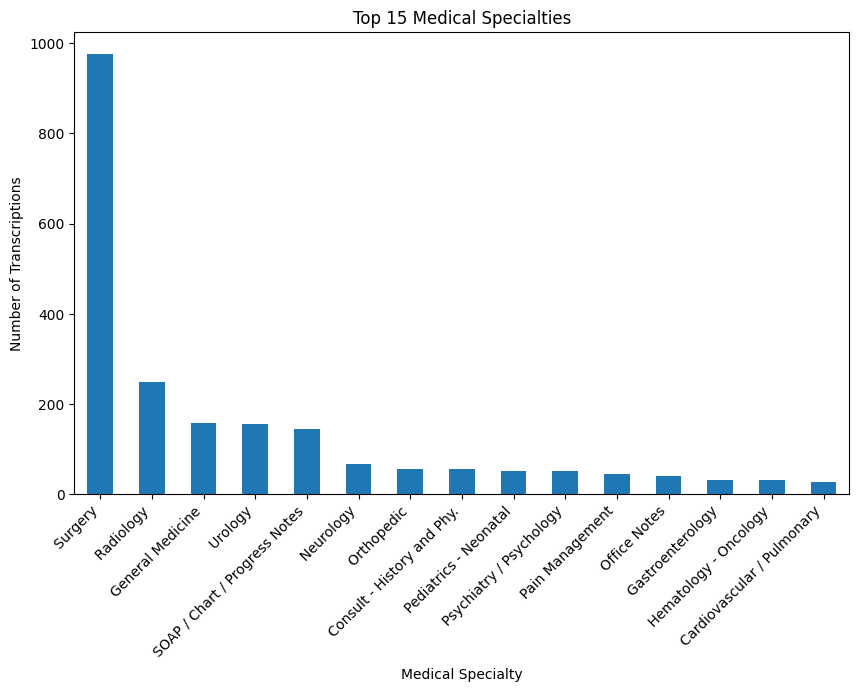

In [ ]:
plt.figure(figsize=(10, 6))

text_df['medical_specialty'].value_counts().head(15).plot(kind='bar')

plt.title('Top 15 Medical Specialties')
plt.xlabel('Medical Specialty')
plt.ylabel('Number of Transcriptions')
plt.xticks(rotation=45, ha='right')

plt.show()

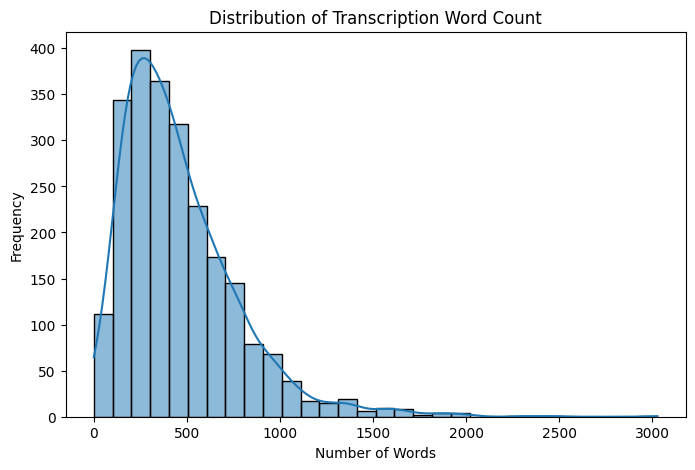

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    text_df['word_count'],
    bins=30,
    kde=True
)

plt.title('Distribution of Transcription Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.show()

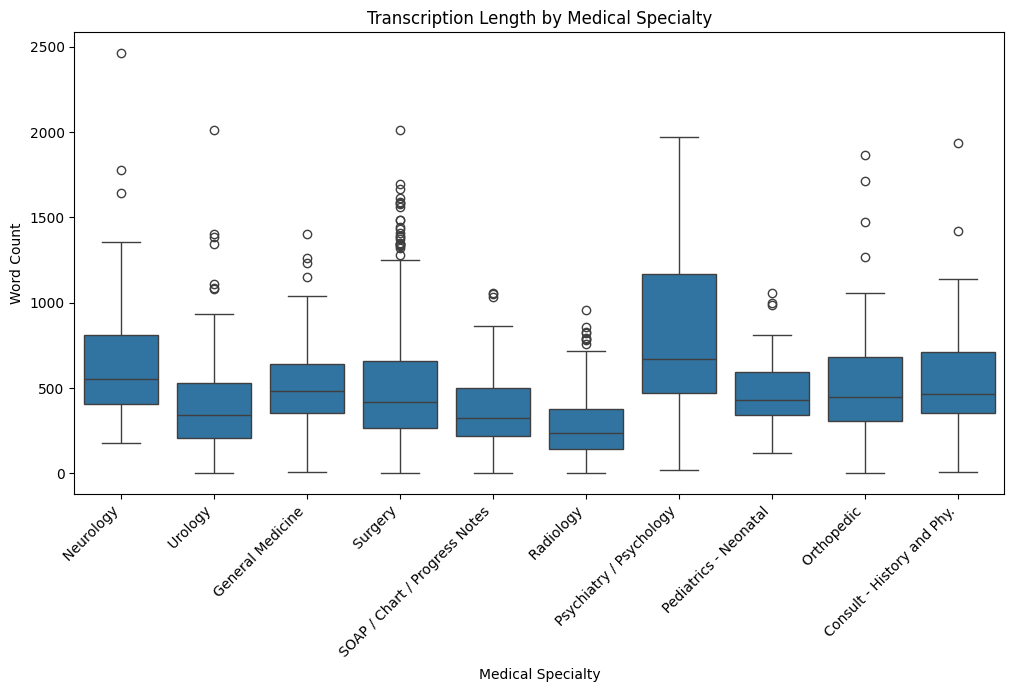

In [ ]:
plt.figure(figsize=(12, 6))

top_specialties = text_df['medical_specialty'].value_counts().head(10).index

sns.boxplot(
    data=text_df[text_df['medical_specialty'].isin(top_specialties)],
    x='medical_specialty',
    y='word_count'
)

plt.title('Transcription Length by Medical Specialty')
plt.xlabel('Medical Specialty')
plt.ylabel('Word Count')
plt.xticks(rotation=45, ha='right')

plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(text_df['clean_text'])

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (2357, 1000)


In [ ]:
feature_names = tfidf.get_feature_names_out()

print("Number of extracted features:", len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])

Number of extracted features: 1000

First 20 features:
['abc' 'abcd' 'abdomen' 'abdominal' 'able' 'abnormal' 'abnormalities'
 'abscess' 'abuse' 'access' 'achieved' 'active' 'activities' 'activity'
 'actually' 'acute' 'addition' 'additional' 'adenopathy' 'adequate']


In [ ]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=feature_names
)

tfidf_df.head()

,abc,abcd,abdomen,abdominal,able,abnormal,abnormalities,abscess,abuse,access,...,withdrawn,woman,work,workup,worse,wound,wrist,xyz,year,years
0,0.000000,0.0,0.000000,0.0,0.0000,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.135054,0.0,0.0,0.000000,0.055453,0.000000
1,0.000000,0.0,0.000000,0.0,0.0000,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.036885,0.064255
2,0.054143,0.0,0.031151,0.0,0.0414,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.056743,0.000000,0.0,0.0,0.160449,0.022372,0.194863
3,0.000000,0.0,0.000000,0.0,0.0000,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
4,0.000000,0.0,0.000000,0.0,0.0000,0.05982,0.062448,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)

X_svd = svd.fit_transform(X_tfidf)

print("Original TF-IDF features:", X_tfidf.shape[1])
print("Reduced features:", X_svd.shape[1])
print("Explained variance ratio:", svd.explained_variance_ratio_)
print("Total explained variance:",
      svd.explained_variance_ratio_.sum())

Original TF-IDF features: 1000
Reduced features: 2
Explained variance ratio: [0.00804645 0.04362663]
Total explained variance: 0.05167308415944935


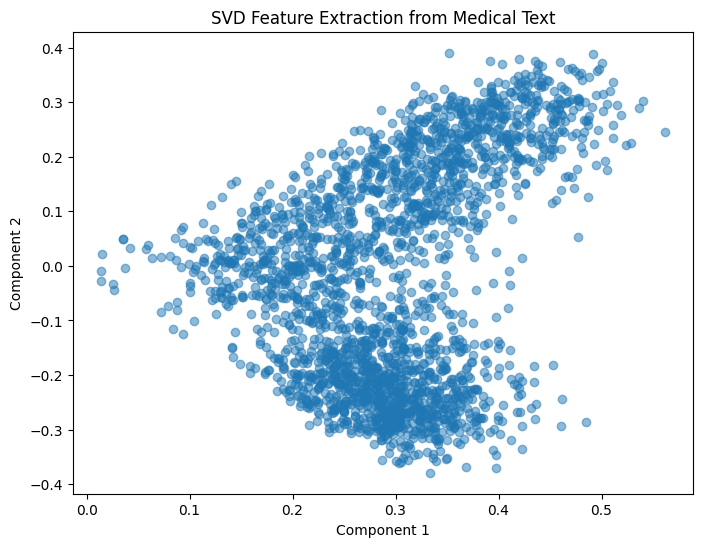

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_svd[:, 0],
    X_svd[:, 1],
    alpha=0.5
)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('SVD Feature Extraction from Medical Text')

plt.show()

In [ ]:
model_ready_text = text_df[
    [
        'medical_specialty',
        'word_count',
        'character_count',
        'sentence_count',
        'clean_text'
    ]
].copy()

model_ready_text.head()

,medical_specialty,word_count,character_count,sentence_count,clean_text
0,Allergy / Immunology,213,1247,27,subjective this year old white female presents...
1,Bariatrics,351,2271,33,past medical history he has difficulty climbin...
2,Bariatrics,709,4117,70,history of present illness i have seen abc tod...
3,Cardiovascular / Pulmonary,63,426,20,d m mode left atrial enlargement with left atr...
4,Cardiovascular / Pulmonary,222,1523,30,the left ventricular cavity size and wall thic...


In [ ]:
print("TF-IDF model-ready shape:", X_tfidf.shape)

TF-IDF model-ready shape: (2357, 1000)


In [ ]:
print("Final number of text records:", len(text_df))
print("TF-IDF representation:", X_tfidf.shape)
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

Final number of text records: 2357
TF-IDF representation: (2357, 1000)
Number of TF-IDF features: 1000


# PART D — SIGNAL DATA
## MIT-BIH Arrhythmia Database (ECG)



In [ ]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.5 MB/s eta 0:00:00


In [ ]:
import wfdb
import os

# Download the MIT-BIH Arrhythmia Database
data_path = '/content/mitdb'

wfdb.dl_database('mitdb', dl_dir=data_path)

print("MIT-BIH database downloaded successfully!")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
import os

for file in sorted(os.listdir('/content/mitdb')):
    print(file)

100.atr
100.dat
100.hea
101.atr
101.dat
101.hea
102.atr
102.dat
102.hea
103.atr
103.dat
103.hea
104.atr
104.dat
104.hea
105.atr
105.dat
105.hea
106.atr
106.dat
106.hea
107.atr
107.dat
107.hea
108.atr
108.dat
108.hea
109.atr
109.dat
109.hea
111.atr
111.dat
111.hea
112.atr
112.dat
112.hea
113.atr
113.dat
113.hea
114.atr
114.dat
114.hea
115.atr
115.dat
115.hea
116.atr
116.dat
116.hea
117.atr
117.dat
117.hea
118.atr
118.dat
118.hea
119.atr
119.dat
119.hea
121.atr
121.dat
121.hea
122.atr
122.dat
122.hea
123.atr
123.dat
123.hea
124.atr
124.dat
124.hea
200.atr
200.dat
200.hea
201.atr
201.dat
201.hea
202.atr
202.dat
202.hea
203.atr
203.dat
203.hea
205.atr
205.dat
205.hea
207.atr
207.dat
207.hea
208.atr
208.dat
208.hea
209.atr
209.dat
209.hea
210.atr
210.dat
210.hea
212.atr
212.dat
212.hea
213.atr
213.dat
213.hea
214.atr
214.dat
214.hea
215.atr
215.dat
215.hea
217.atr
217.dat
217.hea
219.atr
219.dat
219.hea
220.atr
220.dat
220.hea
221.atr
221.dat
221.hea
222.atr
222.dat
222.hea
223.atr
223.dat


In [ ]:
record = wfdb.rdrecord('/content/mitdb/100')

In [ ]:
 # Inspect the ECG record

print("Signal names:", record.sig_name)
print("Sampling frequency:", record.fs, "Hz")
print("Number of signals:", record.n_sig)
print("Number of samples:", record.sig_len)
print("Signal units:", record.units)
print("Signal shape:", record.p_signal.shape)

Signal names: ['MLII', 'V5']
Sampling frequency: 360 Hz
Number of signals: 2
Number of samples: 650000
Signal units: ['mV', 'mV']
Signal shape: (650000, 2)


In [ ]:
# Load ECG beat annotations

annotation = wfdb.rdann('/content/mitdb/100', 'atr')

print("Number of annotations:", len(annotation.sample))
print("First 20 annotation symbols:")
print(annotation.symbol[:20])

Number of annotations: 2274
First 20 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


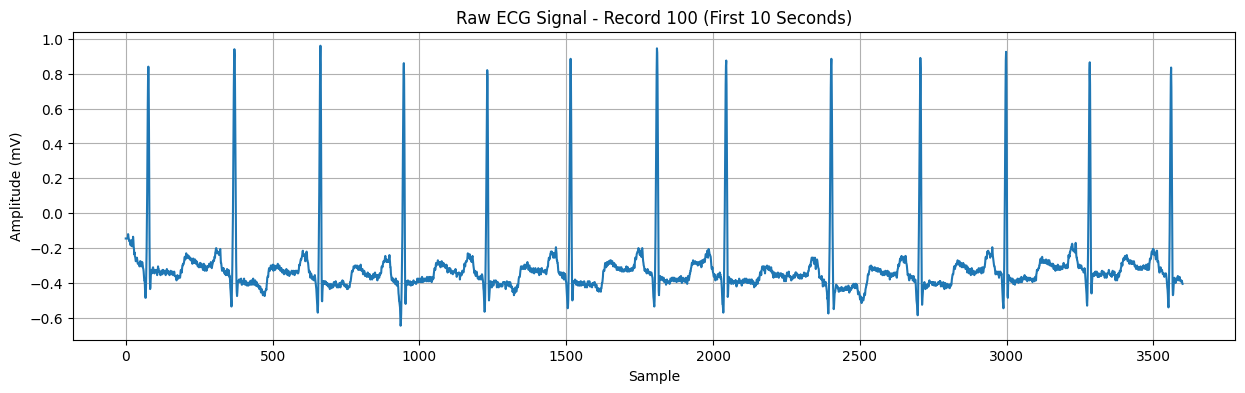

In [ ]:
import matplotlib.pyplot as plt

# Plot first 10 seconds of ECG
duration = 10
samples = int(duration * record.fs)

plt.figure(figsize=(15, 4))
plt.plot(record.p_signal[:samples, 0])
plt.title("Raw ECG Signal - Record 100 (First 10 Seconds)")
plt.xlabel("Sample")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

In [ ]:
# ECG Noise Removal using Band-Pass Filter

from scipy.signal import butter, filtfilt

# Select MLII signal
ecg_raw = record.p_signal[:, 0]

# Band-pass filter: 0.5 Hz to 40 Hz
def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

ecg_filtered = bandpass_filter(
    ecg_raw,
    lowcut=0.5,
    highcut=40,
    fs=record.fs
)

print("Raw ECG shape:", ecg_raw.shape)
print("Filtered ECG shape:", ecg_filtered.shape)

Raw ECG shape: (650000,)
Filtered ECG shape: (650000,)


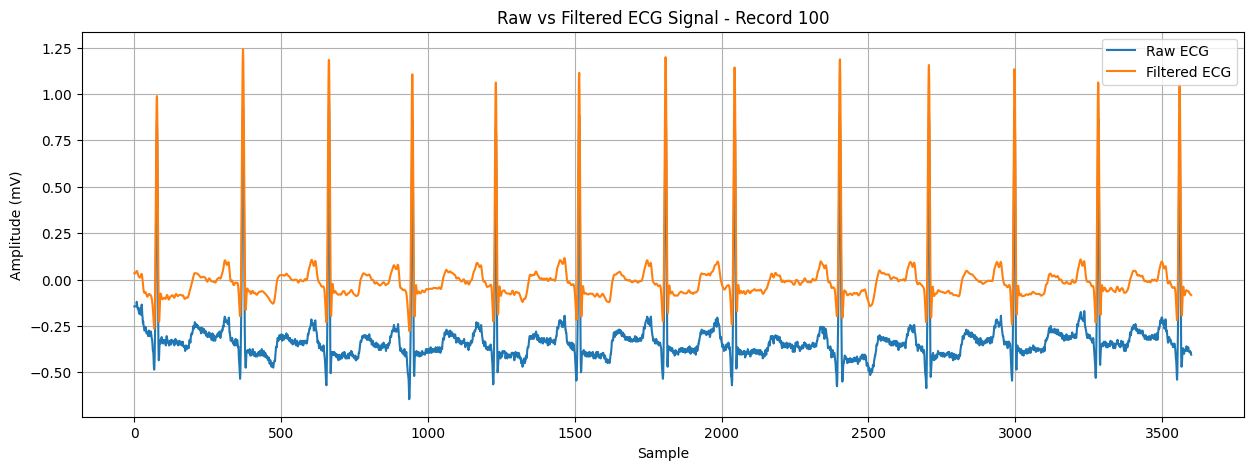

In [ ]:
# Compare Raw and Filtered ECG

duration = 10
samples = int(duration * record.fs)

plt.figure(figsize=(15, 5))

plt.plot(
    ecg_raw[:samples],
    label="Raw ECG"
)

plt.plot(
    ecg_filtered[:samples],
    label="Filtered ECG"
)

plt.title("Raw vs Filtered ECG Signal - Record 100")
plt.xlabel("Sample")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Normalize the filtered ECG signal

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

ecg_normalized = scaler.fit_transform(
    ecg_filtered.reshape(-1, 1)
).flatten()

print("Normalized ECG shape:", ecg_normalized.shape)
print("Mean:", ecg_normalized.mean())
print("Standard deviation:", ecg_normalized.std())

Normalized ECG shape: (650000,)
Mean: -2.7765823828163915e-18
Standard deviation: 1.0


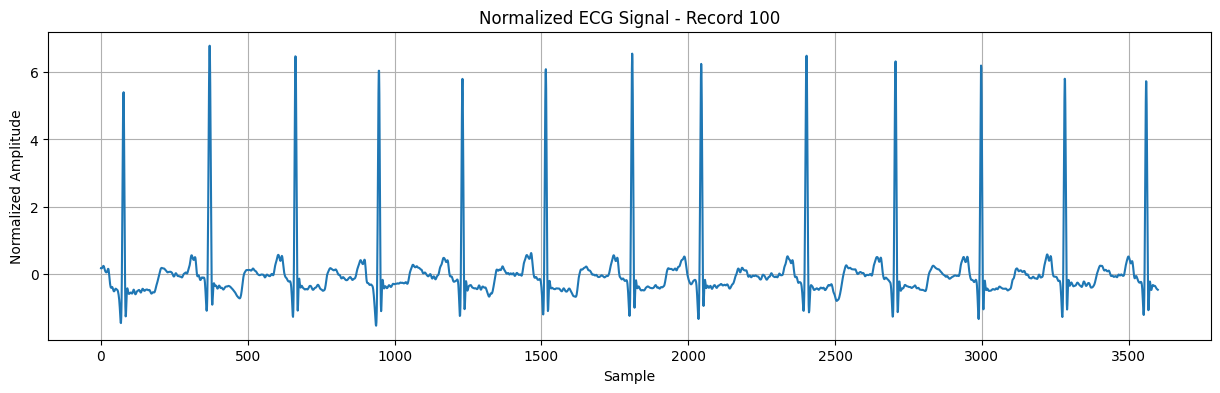

In [ ]:
# Visualize normalized ECG

duration = 10
samples = int(duration * record.fs)

plt.figure(figsize=(15, 4))
plt.plot(ecg_normalized[:samples])

plt.title("Normalized ECG Signal - Record 100")
plt.xlabel("Sample")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.show()

In [ ]:
# Segment ECG into 5-second windows

window_duration = 5  # seconds
window_size = int(window_duration * record.fs)

# Number of complete windows
n_windows = len(ecg_normalized) // window_size

# Remove leftover samples and reshape
windows = ecg_normalized[:n_windows * window_size].reshape(
    n_windows,
    window_size
)

print("Window duration:", window_duration, "seconds")
print("Samples per window:", window_size)
print("Number of windows:", n_windows)
print("Segmented ECG shape:", windows.shape)

Window duration: 5 seconds
Samples per window: 1800
Number of windows: 361
Segmented ECG shape: (361, 1800)


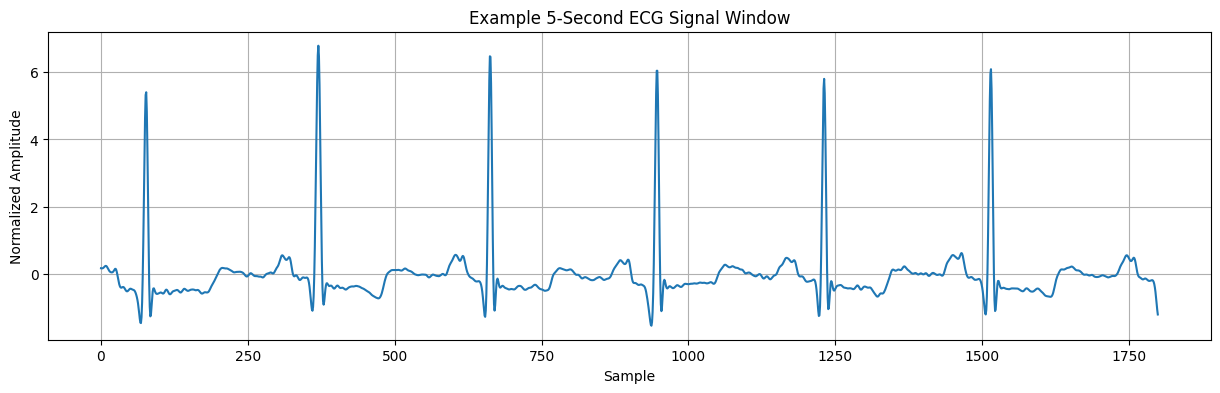

In [ ]:
# Visualize one 5-second ECG window

plt.figure(figsize=(15, 4))

plt.plot(windows[0])

plt.title("Example 5-Second ECG Signal Window")
plt.xlabel("Sample")
plt.ylabel("Normalized Amplitude")
plt.grid(True)

plt.show()

In [ ]:
# Feature Extraction from ECG Windows

import numpy as np
import pandas as pd

features = pd.DataFrame({
    'Mean': np.mean(windows, axis=1),
    'Std': np.std(windows, axis=1),
    'Min': np.min(windows, axis=1),
    'Max': np.max(windows, axis=1),
    'Range': np.ptp(windows, axis=1),
    'RMS': np.sqrt(np.mean(windows**2, axis=1))
})

print("Extracted feature shape:", features.shape)
print("\nFirst 5 rows:")
display(features.head())

Extracted feature shape: (361, 6)

First 5 rows:


,Mean,Std,Min,Max,Range,RMS
0,-0.017559,0.872081,-1.522750,6.779481,8.302231,0.872257
1,0.015614,0.932314,-1.324667,6.544627,7.869294,0.932445
2,-0.005751,0.863053,-1.401064,6.384442,7.785506,0.863073
3,-0.010556,0.920245,-1.342908,6.874545,8.217453,0.920306
4,0.000219,0.929163,-1.429475,7.192523,8.621998,0.929163


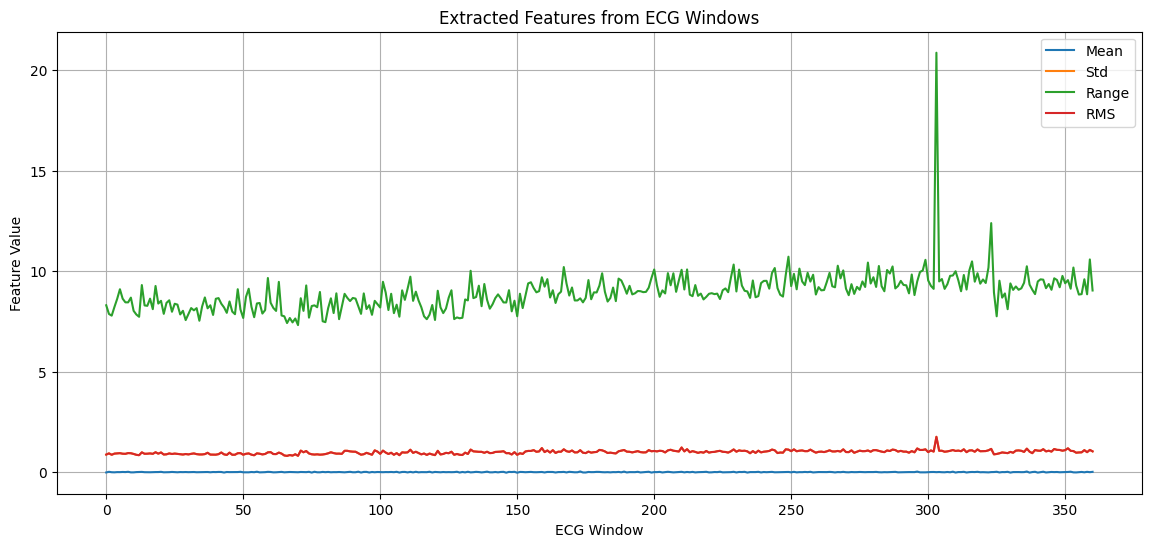

In [ ]:
# Visualize extracted ECG features

features[['Mean', 'Std', 'Range', 'RMS']].plot(
    figsize=(14, 6)
)

plt.title("Extracted Features from ECG Windows")
plt.xlabel("ECG Window")
plt.ylabel("Feature Value")
plt.grid(True)
plt.show()

In [ ]:
# Convert ECG windows to model-ready 3D format

X_signal = windows[..., np.newaxis]

print("Model-ready ECG shape:", X_signal.shape)
print("Number of windows:", X_signal.shape[0])
print("Samples per window:", X_signal.shape[1])
print("Number of channels:", X_signal.shape[2])

Model-ready ECG shape: (361, 1800, 1)
Number of windows: 361
Samples per window: 1800
Number of channels: 1


In [ ]:
# Analyze ECG Annotation Distribution

annotation_counts = pd.Series(annotation.symbol).value_counts()

print("Number of unique annotation symbols:", len(annotation_counts))
print("\nAnnotation distribution:")
display(annotation_counts)

Number of unique annotation symbols: 4

Annotation distribution:


,count
N,2239
A,33
+,1
V,1


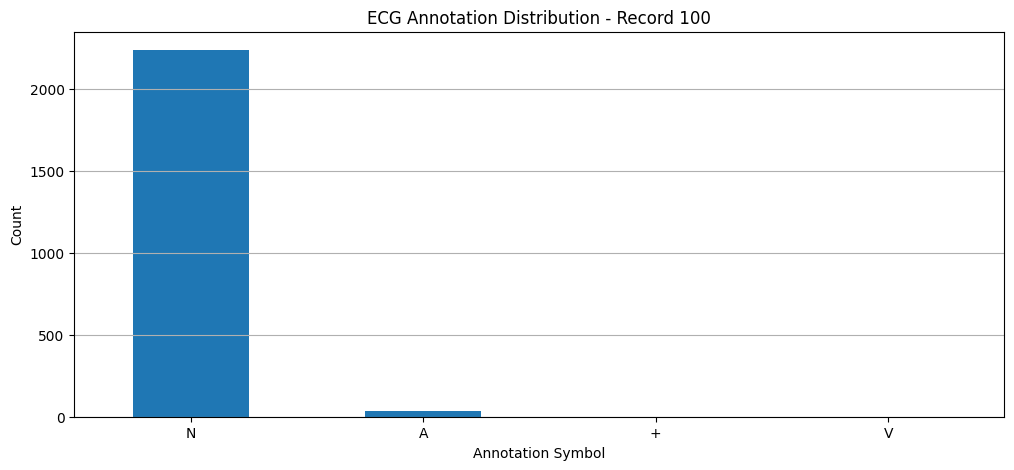

In [ ]:
# Visualize ECG Annotation Distribution

plt.figure(figsize=(12, 5))

annotation_counts.plot(kind='bar')

plt.title("ECG Annotation Distribution - Record 100")
plt.xlabel("Annotation Symbol")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [ ]:
# ECG Signal Augmentation using Small Gaussian Noise

np.random.seed(42)

noise_level = 0.01

noise = np.random.normal(
    loc=0,
    scale=noise_level,
    size=windows.shape
)

augmented_windows = windows + noise

print("Original windows shape:", windows.shape)
print("Augmented windows shape:", augmented_windows.shape)

Original windows shape: (361, 1800)
Augmented windows shape: (361, 1800)


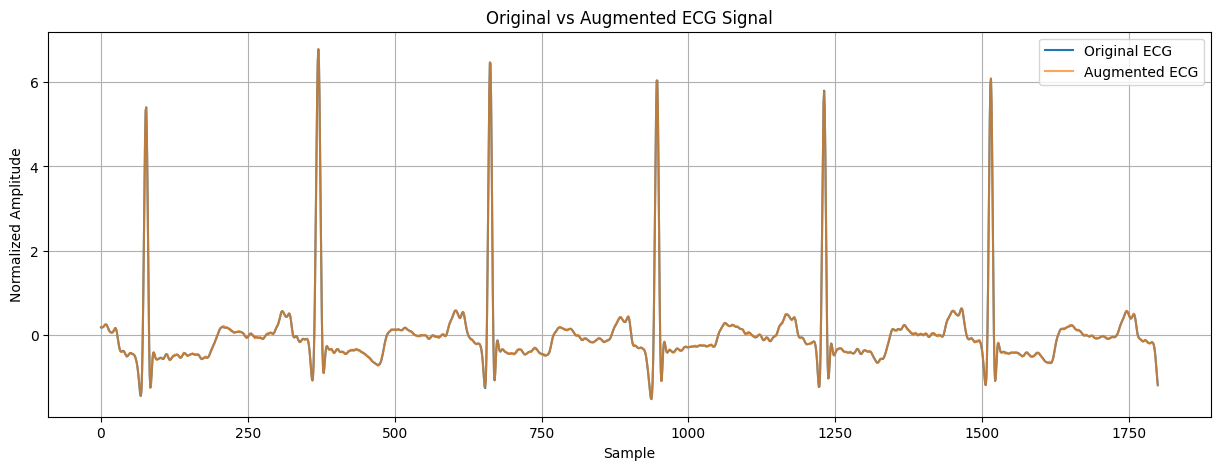

In [ ]:
# Compare Original and Augmented ECG Window

plt.figure(figsize=(15, 5))

plt.plot(
    windows[0],
    label="Original ECG"
)

plt.plot(
    augmented_windows[0],
    label="Augmented ECG",
    alpha=0.7
)

plt.title("Original vs Augmented ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)

plt.show()

# PART C — IMAGE DATA
## Chest X-Ray (Pneumonia) Dataset


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = '/content/drive/MyDrive/AI Healthcare/archive (7).zip'

print("File exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    size_gb = os.path.getsize(zip_path) / (1024**3)
    print("File size:", round(size_gb, 2), "GB")

File exists: True
File size: 2.29 GB


In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as z:
    files = z.namelist()

print("Total files in ZIP:", len(files))

print("\nFirst 30 files/folders:")
for item in files[:30]:
    print(item)

Total files in ZIP: 17591

First 30 files/folders:
chest_xray/__MACOSX/._chest_xray
chest_xray/__MACOSX/chest_xray/._.DS_Store
chest_xray/__MACOSX/chest_xray/._test
chest_xray/__MACOSX/chest_xray/._train
chest_xray/__MACOSX/chest_xray/test/._.DS_Store
chest_xray/__MACOSX/chest_xray/test/._NORMAL
chest_xray/__MACOSX/chest_xray/test/._PNEUMONIA
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0001-0001.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0003-0001.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0005-0001.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0006-0001.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0007-0001.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0009-0001.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0010-0001.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0011-0001-0001.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0011-0001-0002.jpeg
chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0011-0001.jpeg
chest_xray/__MA

In [ ]:
# Find the main Chest X-Ray dataset folders

with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()

# Show important dataset folders only
folders = set()

for file in all_files:
    parts = file.split('/')

    if 'train' in parts or 'test' in parts or 'val' in parts:
        # Keep only the meaningful folder structure
        for i, part in enumerate(parts):
            if part in ['train', 'test', 'val']:
                folders.add('/'.join(parts[:i+2]))

print("Dataset folders found:\n")

for folder in sorted(folders):
    print(folder)

Dataset folders found:

chest_xray/__MACOSX/chest_xray/test/._.DS_Store
chest_xray/__MACOSX/chest_xray/test/._NORMAL
chest_xray/__MACOSX/chest_xray/test/._PNEUMONIA
chest_xray/__MACOSX/chest_xray/test/NORMAL
chest_xray/__MACOSX/chest_xray/test/PNEUMONIA
chest_xray/__MACOSX/chest_xray/train/._.DS_Store
chest_xray/__MACOSX/chest_xray/train/._NORMAL
chest_xray/__MACOSX/chest_xray/train/._PNEUMONIA
chest_xray/__MACOSX/chest_xray/train/NORMAL
chest_xray/__MACOSX/chest_xray/train/PNEUMONIA
chest_xray/__MACOSX/chest_xray/val/._.DS_Store
chest_xray/__MACOSX/chest_xray/val/NORMAL
chest_xray/__MACOSX/chest_xray/val/PNEUMONIA
chest_xray/chest_xray/test/.DS_Store
chest_xray/chest_xray/test/NORMAL
chest_xray/chest_xray/test/PNEUMONIA
chest_xray/chest_xray/train/.DS_Store
chest_xray/chest_xray/train/NORMAL
chest_xray/chest_xray/train/PNEUMONIA
chest_xray/chest_xray/val/.DS_Store
chest_xray/chest_xray/val/NORMAL
chest_xray/chest_xray/val/PNEUMONIA
chest_xray/test/NORMAL
chest_xray/test/PNEUMONIA
ches

In [ ]:
# Extract the Chest X-Ray dataset

import os
import zipfile

extract_path = '/content/chest_xray'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        # Extract only the actual dataset, not __MACOSX
        if file.startswith('chest_xray/chest_xray/'):
            z.extract(file, '/content')

print("Dataset extraction completed!")

Dataset extraction completed!


In [ ]:
# Check the extracted dataset structure

base_path = '/content/chest_xray/chest_xray'

for split in ['train', 'test', 'val']:
    for category in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(base_path, split, category)

        if os.path.exists(folder):
            files = [
                f for f in os.listdir(folder)
                if f.lower().endswith(('.jpeg', '.jpg', '.png'))
            ]

            print(f"{split}/{category}: {len(files)} images")
        else:
            print(f"{split}/{category}: Folder not found")

train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [ ]:
dataset_summary = []

for split in ['train', 'test', 'val']:
    for category in ['NORMAL', 'PNEUMONIA']:

        folder = os.path.join(base_path, split, category)

        image_files = [
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpeg', '.jpg', '.png'))
        ]

        dataset_summary.append({
            'Split': split,
            'Class': category,
            'Number of Images': len(image_files)
        })

summary_df = pd.DataFrame(dataset_summary)

display(summary_df)

,Split,Class,Number of Images
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,test,NORMAL,234
3,test,PNEUMONIA,390
4,val,NORMAL,8
5,val,PNEUMONIA,8


<Figure size 1000x500 with 0 Axes>

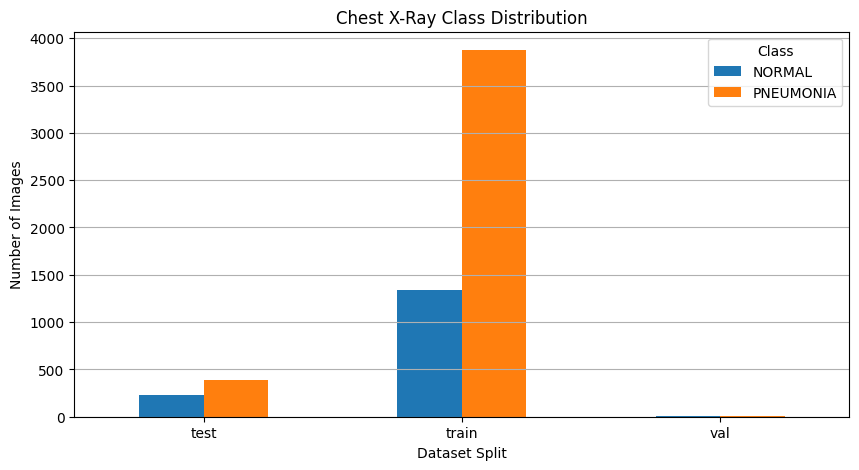

In [ ]:
# Visualize class distribution

plt.figure(figsize=(10, 5))

summary_df.pivot(
    index='Split',
    columns='Class',
    values='Number of Images'
).plot(kind='bar', figsize=(10, 5))

plt.title("Chest X-Ray Class Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(title="Class")

plt.show()

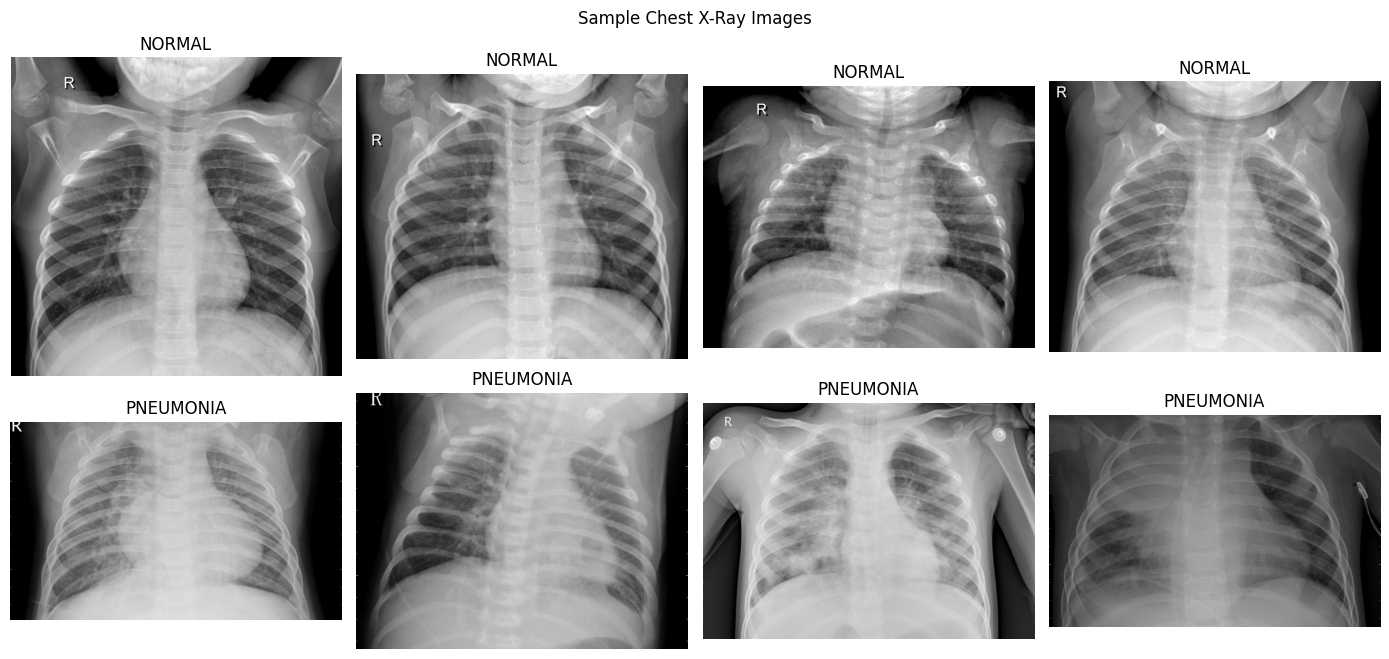

In [ ]:
# Display sample Chest X-Ray images

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

classes = ['NORMAL', 'PNEUMONIA']

for row, category in enumerate(classes):

    folder = os.path.join(base_path, 'train', category)

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ]

    # Select 4 images
    selected_images = image_files[:4]

    for col, image_file in enumerate(selected_images):

        image_path = os.path.join(folder, image_file)
        image = Image.open(image_path)

        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(category)
        axes[row, col].axis('off')

plt.suptitle("Sample Chest X-Ray Images")
plt.tight_layout()
plt.show()

In [ ]:
# Inspect image dimensions, color mode and file format

from collections import Counter

sample_info = []

for category in ['NORMAL', 'PNEUMONIA']:

    folder = os.path.join(base_path, 'train', category)

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ]

    # Inspect first 100 images from each class
    for image_file in image_files[:100]:

        image_path = os.path.join(folder, image_file)

        try:
            with Image.open(image_path) as img:
                sample_info.append({
                    'Class': category,
                    'Width': img.width,
                    'Height': img.height,
                    'Mode': img.mode,
                    'Format': img.format
                })
        except Exception:
            pass

image_info_df = pd.DataFrame(sample_info)

print("Number of images inspected:", len(image_info_df))

print("\nImage modes:")
print(image_info_df['Mode'].value_counts())

print("\nImage formats:")
print(image_info_df['Format'].value_counts())

print("\nUnique image dimensions:")
display(
    image_info_df[['Width', 'Height']]
    .value_counts()
    .reset_index(name='Count')
    .head(15)
)

Number of images inspected: 200

Image modes:
Mode
L      193
RGB      7
Name: count, dtype: int64

Image formats:
Format
JPEG    200
Name: count, dtype: int64

Unique image dimensions:


,Width,Height,Count
0,952,560,2
1,1328,936,2
2,759,409,1
3,791,615,1
4,816,504,1
5,445,232,1
6,816,584,1
7,831,603,1
8,856,632,1
9,848,552,1


In [ ]:
# Check for corrupted or unreadable images

corrupted_images = []

for split in ['train', 'test', 'val']:
    for category in ['NORMAL', 'PNEUMONIA']:

        folder = os.path.join(base_path, split, category)

        for image_file in os.listdir(folder):

            if not image_file.lower().endswith(('.jpeg', '.jpg', '.png')):
                continue

            image_path = os.path.join(folder, image_file)

            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                corrupted_images.append(image_path)

print("Number of corrupted/unreadable images:", len(corrupted_images))

if len(corrupted_images) > 0:
    print("\nFirst few corrupted files:")
    print(corrupted_images[:10])
else:
    print("No corrupted images detected.")

Number of corrupted/unreadable images: 0
No corrupted images detected.


In [ ]:
# Check for embedded image metadata (EXIF)

metadata_found = []

for split in ['train', 'test', 'val']:
    for category in ['NORMAL', 'PNEUMONIA']:

        folder = os.path.join(base_path, split, category)

        image_files = [
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpeg', '.jpg', '.png'))
        ]

        for image_file in image_files[:20]:

            image_path = os.path.join(folder, image_file)

            try:
                with Image.open(image_path) as img:
                    exif_data = img.getexif()

                    if len(exif_data) > 0:
                        metadata_found.append({
                            'File': image_file,
                            'Metadata': dict(exif_data)
                        })

            except Exception:
                pass

print("Images with embedded EXIF metadata:", len(metadata_found))

if len(metadata_found) == 0:
    print("No EXIF metadata detected in the inspected images.")
else:
    print("\nExample metadata:")
    display(pd.DataFrame(metadata_found).head())

Images with embedded EXIF metadata: 31

Example metadata:


,File,Metadata
0,NORMAL2-IM-1343-0001.jpeg,{34665: 26}
1,IM-0620-0001-0002.jpeg,{34665: 26}
2,IM-0584-0001.jpeg,{34665: 26}
3,IM-0652-0001-0002.jpeg,{34665: 26}
4,NORMAL2-IM-0454-0001.jpeg,{34665: 26}


In [ ]:
# Resize and normalize Chest X-Ray images

IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    """
    Load an X-ray image, convert to grayscale,
    resize to 224x224 and normalize pixel values to [0, 1].
    """

    image = Image.open(image_path).convert('L')
    image = image.resize(IMG_SIZE)

    image_array = np.array(image, dtype=np.float32)
    image_array = image_array / 255.0

    return image_array


# Test preprocessing on one image
sample_path = os.path.join(
    base_path,
    'train',
    'NORMAL',
    os.listdir(os.path.join(base_path, 'train', 'NORMAL'))[0]
)

processed_image = preprocess_image(sample_path)

print("Processed image shape:", processed_image.shape)
print("Minimum pixel value:", processed_image.min())
print("Maximum pixel value:", processed_image.max())

Processed image shape: (224, 224)
Minimum pixel value: 0.0
Maximum pixel value: 0.96862745


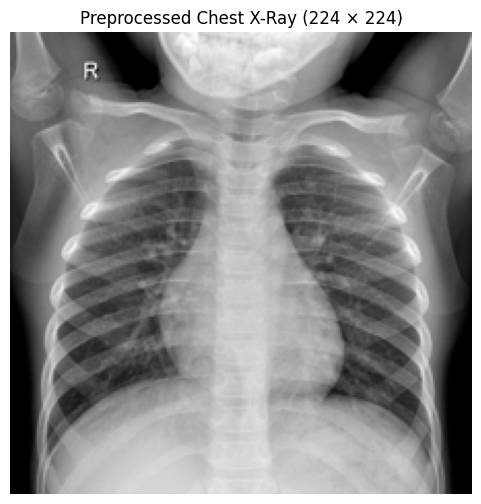

In [ ]:
# Visualize the resized and normalized X-ray

plt.figure(figsize=(6, 6))

plt.imshow(processed_image, cmap='gray')
plt.title("Preprocessed Chest X-Ray (224 × 224)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.axis('off')

plt.show()

In [ ]:
# Remove EXIF metadata from a sample of X-ray images

clean_image_dir = '/content/clean_xray_samples'

os.makedirs(clean_image_dir, exist_ok=True)

metadata_removed = 0

for category in ['NORMAL', 'PNEUMONIA']:

    source_folder = os.path.join(base_path, 'train', category)

    image_files = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ][:20]

    category_dir = os.path.join(clean_image_dir, category)
    os.makedirs(category_dir, exist_ok=True)

    for image_file in image_files:

        source_path = os.path.join(source_folder, image_file)
        output_path = os.path.join(category_dir, image_file)

        with Image.open(source_path) as img:
            # Convert to grayscale and save without EXIF metadata
            clean_img = img.convert('L')
            clean_img.save(output_path)

        metadata_removed += 1

print("Images processed for metadata removal:", metadata_removed)

Images processed for metadata removal: 40


In [ ]:
# Verify that EXIF metadata has been removed

remaining_metadata = 0

for category in ['NORMAL', 'PNEUMONIA']:

    folder = os.path.join(clean_image_dir, category)

    for image_file in os.listdir(folder):

        image_path = os.path.join(folder, image_file)

        with Image.open(image_path) as img:
            if len(img.getexif()) > 0:
                remaining_metadata += 1

print("Images with EXIF metadata after cleaning:", remaining_metadata)

if remaining_metadata == 0:
    print("EXIF metadata successfully removed.")

Images with EXIF metadata after cleaning: 0
EXIF metadata successfully removed.


In [ ]:
# Import image augmentation tools

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True
)

print("Image augmentation pipeline created.")

Image augmentation pipeline created.


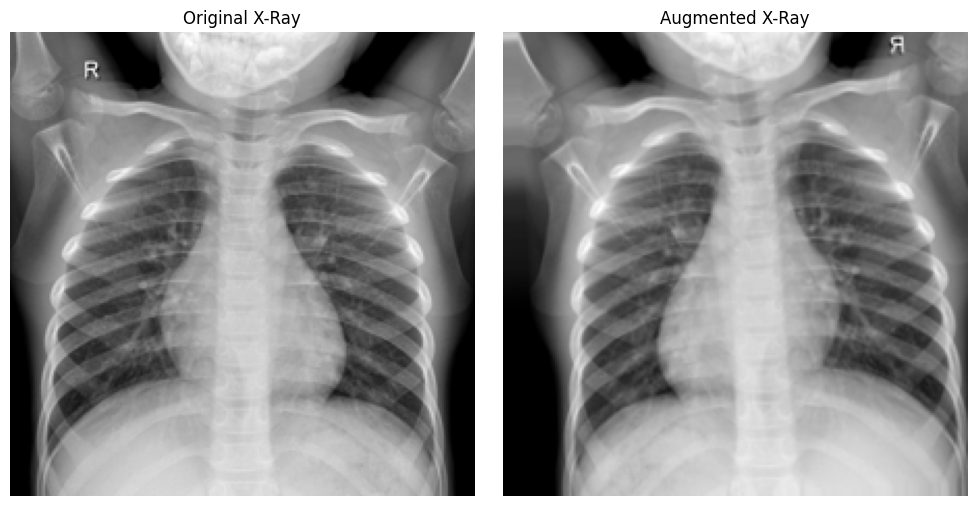

In [ ]:
# Generate an augmented X-ray image

sample_image = processed_image.reshape(1, 224, 224, 1)

augmentation_generator = datagen.flow(
    sample_image,
    batch_size=1,
    seed=42
)

augmented_image = next(augmentation_generator)[0].squeeze()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(processed_image, cmap='gray')
plt.title("Original X-Ray")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented_image, cmap='gray')
plt.title("Augmented X-Ray")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Extract numerical features from Chest X-Ray images

def extract_image_features(image_array):
    features = {
        'Mean_Intensity': np.mean(image_array),
        'Std_Intensity': np.std(image_array),
        'Min_Intensity': np.min(image_array),
        'Max_Intensity': np.max(image_array),
        'Intensity_Range': np.ptp(image_array),
        'RMS_Intensity': np.sqrt(np.mean(image_array ** 2))
    }

    return features


feature_records = []

# Extract features from 100 images from each class
for category in ['NORMAL', 'PNEUMONIA']:

    folder = os.path.join(base_path, 'train', category)

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ][:100]

    for image_file in image_files:

        image_path = os.path.join(folder, image_file)
        image_array = preprocess_image(image_path)

        features_dict = extract_image_features(image_array)
        features_dict['Class'] = category

        feature_records.append(features_dict)


image_features_df = pd.DataFrame(feature_records)

print("Feature dataset shape:", image_features_df.shape)

display(image_features_df.head())

Feature dataset shape: (200, 7)


,Mean_Intensity,Std_Intensity,Min_Intensity,Max_Intensity,Intensity_Range,RMS_Intensity,Class
0,0.495928,0.227049,0.0,0.968627,0.968627,0.545432,NORMAL
1,0.516164,0.221204,0.0,1.000000,1.000000,0.561566,NORMAL
2,0.454710,0.242777,0.0,1.000000,1.000000,0.515462,NORMAL
3,0.513694,0.254487,0.0,0.992157,0.992157,0.573276,NORMAL
4,0.477336,0.249382,0.0,1.000000,1.000000,0.538554,NORMAL


<Figure size 1000x600 with 0 Axes>

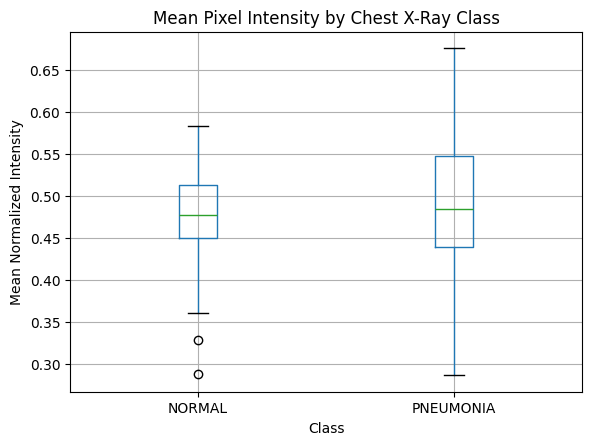

In [ ]:
# Visualize image intensity features by class

plt.figure(figsize=(10, 6))

image_features_df.boxplot(
    column='Mean_Intensity',
    by='Class'
)

plt.title("Mean Pixel Intensity by Chest X-Ray Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Mean Normalized Intensity")

plt.show()

In [ ]:
# Create model-ready image tensors

IMAGE_SAMPLES_PER_CLASS = 200

X_images = []
y_images = []

for label, category in enumerate(['NORMAL', 'PNEUMONIA']):

    folder = os.path.join(base_path, 'train', category)

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ][:IMAGE_SAMPLES_PER_CLASS]

    for image_file in image_files:

        image_path = os.path.join(folder, image_file)

        image_array = preprocess_image(image_path)

        # Add channel dimension
        image_array = image_array[..., np.newaxis]

        X_images.append(image_array)
        y_images.append(label)


X_images = np.array(X_images, dtype=np.float32)
y_images = np.array(y_images)

print("Model-ready image shape:", X_images.shape)
print("Labels shape:", y_images.shape)
print("Number of NORMAL images:", np.sum(y_images == 0))
print("Number of PNEUMONIA images:", np.sum(y_images == 1))

Model-ready image shape: (400, 224, 224, 1)
Labels shape: (400,)
Number of NORMAL images: 200
Number of PNEUMONIA images: 200


In [ ]:
# PCA-based feature extraction

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_columns = [
    'Mean_Intensity',
    'Std_Intensity',
    'Min_Intensity',
    'Max_Intensity',
    'Intensity_Range',
    'RMS_Intensity'
]

X_features = image_features_df[feature_columns]

# Standardize features
feature_scaler = StandardScaler()
X_features_scaled = feature_scaler.fit_transform(X_features)

# Extract 2 principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_features_scaled)

print("Original feature shape:", X_features.shape)
print("PCA feature shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original feature shape: (200, 6)
PCA feature shape: (200, 2)
Explained variance ratio: [0.49154362 0.322861  ]
Total explained variance: 0.8144046


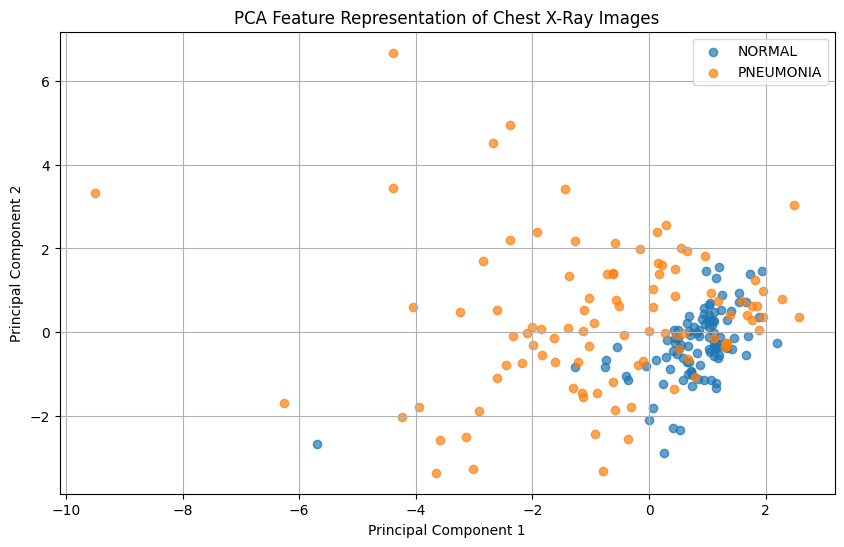

In [ ]:
# Visualize PCA feature representation

plt.figure(figsize=(10, 6))

for label, category in enumerate(['NORMAL', 'PNEUMONIA']):

    mask = image_features_df['Class'] == category

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=category,
        alpha=0.7
    )

plt.title("PCA Feature Representation of Chest X-Ray Images")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Final verification of model-ready image data

print("========== FINAL IMAGE DATA CHECK ==========")

print("Image tensor shape:", X_images.shape)
print("Label shape:", y_images.shape)

print("\nPixel value range:")
print("Minimum:", X_images.min())
print("Maximum:", X_images.max())

print("\nClass labels:")
print("0 = NORMAL")
print("1 = PNEUMONIA")

print("\nClass distribution in model-ready subset:")
print("NORMAL:", np.sum(y_images == 0))
print("PNEUMONIA:", np.sum(y_images == 1))

========== FINAL IMAGE DATA CHECK ==========
Image tensor shape: (400, 224, 224, 1)
Label shape: (400,)

Pixel value range:
Minimum: 0.0
Maximum: 1.0

Class labels:
0 = NORMAL
1 = PNEUMONIA

Class distribution in model-ready subset:
NORMAL: 200
PNEUMONIA: 200
